# 04 — Validação do índice

**Secção da dissertação:** 3.5.8.

Duas frentes testáveis agora: (1) validade de critério externo — duração
observada ~ ICP + controlos, contra um modelo-base sem ICP; (2) validade
convergente/discriminante — Spearman entre c̄ e H̄ (expectativa: *moderada*)
e correlação com proxies procedimentais (códigos TPU em `config.py`, TODO).


In [1]:
# Arranque reproduzível: funciona a partir da raiz ou de notebooks/.
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

def raiz_projeto() -> Path:
    cwd = Path.cwd().resolve()
    for cand in (cwd, cwd.parent, Path(".").resolve()):
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Não encontrei a raiz do projecto (pasta src/).")

RAIZ = raiz_projeto()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.caminhos import garantir_directorias
from src.config import aviso_parametros_pendentes, parametros_efectivos
from src.graficos_apa import CatalogoAPA, aplicar_estilo_apa, formatar_p

DIRS = garantir_directorias(RAIZ)
PARAM = parametros_efectivos(DIRS["processado"])
aplicar_estilo_apa()

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 88)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 160)

print(aviso_parametros_pendentes(PARAM))
print("Raiz:", RAIZ)


AVISO METODOLÓGICO — parâmetros ainda não validados com o orientador.
  Limiar mínimo de movimentos: 7 (EDA (parametros_sugeridos.json))
  Ano-base da normalização: 2016 (EDA (parametros_sugeridos.json))
  Coortes: [('TRF2', 2016), ('TRF2', 2017), ('TRF2', 2018), ('TRF2', 2019), ('TRF2', 2020), ('TRF2', 2021), ('TRF2', 2022), ('TRF2', 2023), ('TRF2', 2024)] (EDA (parametros_sugeridos.json))
  O índice produzido nesta corrida é operacional, não a versão final da dissertação.
Raiz: /workspace


In [2]:
from IPython.display import display
from src.validacao import (
    indicadores_proxies,
    quadro_coeficientes_apa,
    regressao_criterio_externo,
    validade_convergente_discriminante,
)
from src.config import CODIGOS_MOVIMENTO_PROCEDIMENTAIS

parquet = DIRS["processado"] / "indice.parquet"
if not parquet.exists():
    raise FileNotFoundError(
        f"Artefacto em falta: {parquet}. Corra 03_construcao_indice.ipynb primeiro."
    )
quadro = pd.read_parquet(parquet)
catalogo = CatalogoAPA(
    DIRS["figuras"], DIRS["tabelas"],
    DIRS["saidas"] / "relatorio_resultados.md",
    reiniciar_relatorio=False,
)
print("N:", len(quadro))
print("Proxies configurados (TODO):", {k: v for k, v in CODIGOS_MOVIMENTO_PROCEDIMENTAIS.items()})


N: 5247
Proxies configurados (TODO): {'pericia': [417, 418, 419, 1051], 'carta_precatoria': [], 'incidente_processual': [272, 12098], 'redistribuicao': [36, 1013], 'recurso': [265, 1060, 235, 230, 11975, 239, 240], 'suspensao': [898, 264, 25, 11025]}


## Validade de critério externo

A duração (ajuizamento → último movimento) **nunca** entrou no ICP. Um
coeficiente significativo e um ΔR² positivo não «provam» o índice, mas
mostram que ele não é ortogonal a um critério que a literatura associa a
tramitações mais complexas. Controlamos classe, coorte, grau (se variar)
e o comprimento da sequência — este último como covariável, não como
componente (secção 3.4), para o ICP não ser só um proxy de n.


n OLS = 5247
R² base (sem ICP) = 0.9898
R² com ICP        = 0.9898
ΔR²               = 0.0000
                            OLS Regression Results                            
Dep. Variable:           duracao_dias   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 2.411e+04
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:39:18   Log-Likelihood:                -31207.
No. Observations:                5247   AIC:                         6.246e+04
Df Residuals:                    5225   BIC:                         6.260e+04
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
                                                                   coef    std err          t      P>|t|      [0.025

Variável,B,EP,IC 95% inf.,IC 95% sup.,t,p,p (APA)
Intercept,3110.853,11.080,3089.132,3132.574,280.768,0.000,p < .001
C(coorte)[T.2017],-322.320,5.233,-332.579,-312.061,-61.594,0.000,p < .001
C(coorte)[T.2018],-698.788,5.437,-709.446,-688.129,-128.533,0.000,p < .001
C(coorte)[T.2019],-1142.053,5.962,-1153.740,-1130.366,-191.571,0.000,p < .001
C(coorte)[T.2020],-1454.403,5.455,-1465.098,-1443.709,-266.603,0.000,p < .001
C(coorte)[T.2021],-1825.296,5.899,-1836.860,-1813.731,-309.427,0.000,p < .001
C(coorte)[T.2022],-2207.718,5.550,-2218.598,-2196.839,-397.813,0.000,p < .001
C(coorte)[T.2023],-2570.348,5.996,-2582.102,-2558.595,-428.712,0.000,p < .001
C(coorte)[T.2024],-2836.410,6.821,-2849.783,-2823.037,-415.813,0.000,p < .001
icp,-8.981,9.188,-26.994,9.032,-0.977,0.328,p = .328


modelo,R²,R² ajustado,ΔR²,n
"Base (classe, coorte, n movimentos)",0.99,0.99,—,5247.00
Base + ICP,0.99,0.99,0.00,5247.00


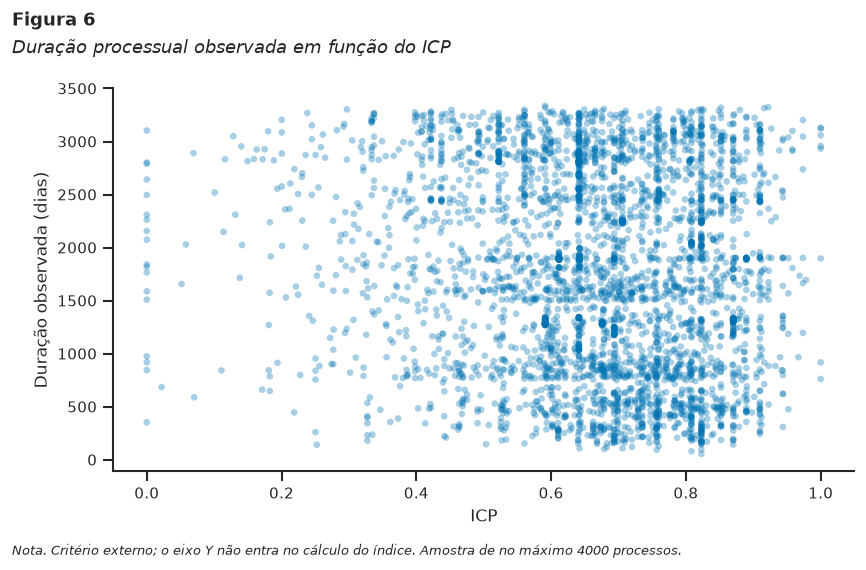

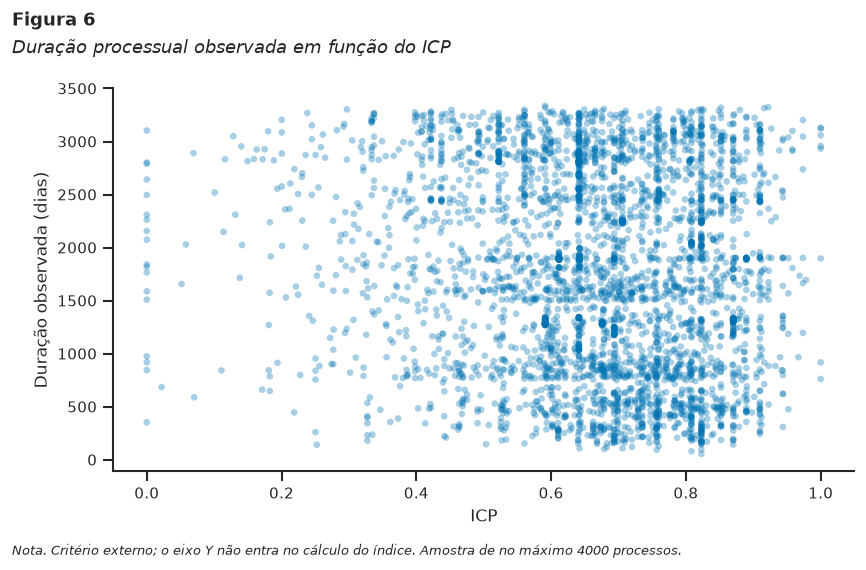

In [3]:
resultados = regressao_criterio_externo(quadro)
print(f"n OLS = {resultados['n']}")
print(f"R² base (sem ICP) = {resultados['r2_base']:.4f}")
print(f"R² com ICP        = {resultados['r2_icp']:.4f}")
print(f"ΔR²               = {resultados['delta_r2']:.4f}")
print(resultados["modelo_icp"].summary())

coef = quadro_coeficientes_apa(resultados["modelo_icp"])
# Tabela empírica: não imprimir dezenas de dummies de classe no corpo principal —
# mostramos o ICP, n_movimentos e o intercepto; o CSV completo fica em /outputs.
coef_resumo = coef[coef["Variável"].isin(["Intercept", "icp", "n_movimentos"]) | coef["Variável"].str.startswith("C(coorte)")].copy()
catalogo.nova_tabela(
    coef_resumo,
    titulo="Regressão da duração observada (dias) sobre o ICP, com controlos (coeficientes seleccionados)",
    nota=(
        f"OLS. Variável dependente = duração em dias entre dataAjuizamento e o último movimento. "
        f"Controlos omitidos da tabela (presentes no modelo): classe agrupada (top 8 + Outras)"
        f"{', grau' if resultados['incluir_grau'] else ''}{', tribunal' if resultados['incluir_tribunal'] else ''}. "
        f"R² modelo-base = {resultados['r2_base']:.2f}; R² modelo com ICP = {resultados['r2_icp']:.2f}; "
        f"ΔR² = {resultados['delta_r2']:.2f}. n = {resultados['n']}. "
        "p-valores em formato APA (sem zero à esquerda). CSV completo na pasta de tabelas."
    ),
    nome_ficheiro="tabela_regressao_criterio_externo",
    interpretacao=(
        f"O ΔR² de {resultados['delta_r2']:.3f} é o ganho de poder explicativo atribuível ao ICP "
        "depois de controlar classe, coorte e comprimento da sequência. Um ΔR² residual sugere que "
        "o índice não é redutível a n nem à composição por classe; um ΔR² nulo exigiria rever a arquitectura."
    ),
    casas=3,
)
coef.to_csv(DIRS["tabelas"] / "tabela_regressao_criterio_externo_completa.csv", index=False)

resumo_r2 = pd.DataFrame({
    "modelo": ["Base (classe, coorte, n movimentos)", "Base + ICP"],
    "R²": [resultados["r2_base"], resultados["r2_icp"]],
    "R² ajustado": [resultados["r2_ajustado_base"], resultados["r2_ajustado_icp"]],
    "ΔR²": [np.nan, resultados["delta_r2"]],
    "n": [resultados["n"], resultados["n"]],
})
catalogo.nova_tabela(
    resumo_r2,
    titulo="Comparação do poder explicativo: modelo-base versus modelo com ICP",
    nota="O modelo-base usa apenas controlos (sem o índice). ΔR² = R²(com ICP) − R²(base).",
    nome_ficheiro="tabela_delta_r2_icp",
    interpretacao="Esta é a métrica-resumo da validade de critério externo pedida na secção 3.5.8: o que o ICP acrescenta para além da classe e do comprimento.",
)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
amostra = quadro.dropna(subset=["icp", "duracao_dias"]).sample(min(len(quadro), 4000), random_state=42)
sns.scatterplot(data=amostra, x="icp", y="duracao_dias", ax=ax, alpha=0.35, s=16, edgecolor="none",
                color=sns.color_palette("colorblind")[0])
ax.set_xlabel("ICP")
ax.set_ylabel("Duração observada (dias)")
catalogo.nova_figura(
    fig,
    titulo="Duração processual observada em função do ICP",
    nota="Critério externo; o eixo Y não entra no cálculo do índice. Amostra de no máximo 4000 processos.",
    nome_ficheiro="figura_dispersao_icp_duracao",
    interpretacao="A nuvem deve mostrar associação positiva se o ICP capturar tramitações que, mesmo controlando n, demoram mais; heterocedasticidade é esperada e o OLS aqui é descritivo.",
)


## Duração residualizada na coorte (leitura correcta desta extração)

Todos os processos desta amostra têm **baixa definitiva em 2025**. A duração observada é, por construção, quase uma função linear do ano de ajuizamento: um processo de 2016 dura ~9 anos, um de 2024 ~1 ano. Por isso `C(coorte)` no modelo anterior absorve a maior parte da variância (R² ≈ .99) e o ΔR² do ICP cai mecanicamente a zero — **não é evidência contra o índice**, é um artefacto do desenho amostral.

A especificação abaixo residualiza duração e ICP *dentro* de cada coorte (equivalente a efeitos fixos de painel) e volta a controlar classe e comprimento. É esta a variação que a secção 3.5.8 consegue testar com os dados actuais.

In [4]:
from src.validacao import regressao_within_coorte

within = regressao_within_coorte(quadro)
print(f"n = {within['n']}")
print(f"R² base (duração residual ~ classe + n) = {within['r2_base']:.4f}")
print(f"R² com ICP residual                    = {within['r2_icp']:.4f}")
print(f"ΔR²                                    = {within['delta_r2']:.4f}")
print(f"coef. ICP (dias por unidade de ICP, within) = {within['coef_icp']:.3f}")
print(f"{formatar_p(within['p_icp'])}")

coef_w = quadro_coeficientes_apa(within["modelo_icp"])
coef_w_resumo = coef_w[coef_w["Variável"].isin(["Intercept", "icp_wc", "n_movimentos"])].copy()
catalogo.nova_tabela(
    coef_w_resumo,
    titulo="Regressão within-coorte: duração residualizada sobre o ICP residualizado",
    nota=(
        "Duração e ICP descontados da média da respectiva coorte de ajuizamento "
        "(efeitos fixos). Controlos: classe agrupada e n_movimentos"
        + (", grau" if quadro["grau"].nunique() > 1 else "")
        + f". R² base = {within['r2_base']:.4f}; R² com ICP = {within['r2_icp']:.4f}; "
        f"ΔR² = {within['delta_r2']:.4f}. n = {within['n']}. "
        "Esta especificação evita a colinearidade coorte–duração da extração com baixa no mesmo ano civil."
    ),
    nome_ficheiro="tabela_regressao_within_coorte",
    interpretacao=(
        f"Dentro da coorte, o ICP residualizado associa-se à duração residual com "
        f"B = {within['coef_icp']:.2f} dias ({formatar_p(within['p_icp'])}) e ΔR² = {within['delta_r2']:.4f}. "
        "É este o teste de critério externo interpretável nesta amostra; o ΔR² nulo do modelo com dummies de coorte era esperado pelo desenho da extração."
    ),
    casas=3,
)

resumo_w = pd.DataFrame({
    "modelo": [
        "Duração ~ coorte + classe + n (sem ICP)",
        "Duração ~ coorte + classe + n + ICP",
        "Duração residual ~ classe + n (within, sem ICP)",
        "Duração residual ~ classe + n + ICP residual (within)",
    ],
    "R²": [
        resultados["r2_base"], resultados["r2_icp"],
        within["r2_base"], within["r2_icp"],
    ],
    "ΔR² vs. o seu base": [
        np.nan, resultados["delta_r2"],
        np.nan, within["delta_r2"],
    ],
})
catalogo.nova_tabela(
    resumo_w,
    titulo="Poder explicativo do ICP: modelo com dummies de coorte versus modelo within-coorte",
    nota="As duas primeiras linhas repetem a Tabela anterior (R² inflacionado pela coorte). As duas últimas isolam a variação intra-painel.",
    nome_ficheiro="tabela_r2_within_vs_coorte",
    interpretacao="Ler o ΔR² within, não o ΔR² com dummies de ano, quando todos os processos encerram no mesmo ano civil.",
    casas=4,
)

n = 5247
R² base (duração residual ~ classe + n) = 0.0363
R² com ICP residual                    = 0.0369
ΔR²                                    = 0.0006
coef. ICP (dias por unidade de ICP, within) = -16.086
p = .075


Variável,B,EP,IC 95% inf.,IC 95% sup.,t,p,p (APA)
Intercept,0.117,6.829,-13.270,13.504,0.017,0.986,p = .986
icp_wc,-16.086,9.026,-33.780,1.608,-1.782,0.075,p = .075
n_movimentos,0.348,0.210,-0.065,0.760,1.652,0.099,p = .099


modelo,R²,ΔR² vs. o seu base
Duração ~ coorte + classe + n (sem ICP),0.9898,—
Duração ~ coorte + classe + n + ICP,0.9898,0.0000
"Duração residual ~ classe + n (within, sem ICP)",0.0363,—
Duração residual ~ classe + n + ICP residual (within),0.0369,0.0006


,modelo,R²,ΔR² vs. o seu base
0,Duração ~ coorte + classe + n (sem ICP),0.989783,NaN
1,Duração ~ coorte + classe + n + ICP,0.989785,0.000002
2,"Duração residual ~ classe + n (within, sem ICP)",0.036269,NaN
3,Duração residual ~ classe + n + ICP residual (within),0.036854,0.000585


## Validade convergente e discriminante

Expectativa teórica: Spearman entre c̄ e H̄ **moderada** (nem ~0 nem ~1).
Os proxies (perícia, carta precatória, incidente, redistribuição, recurso,
suspensão) são códigos TPU em `config.py` e ainda estão por confirmar.
Nesta amostra TRF2, perícia e carta precatória podem ter prevalência zero —
isso limita o teste, não se «inventam» associações.


In [5]:
quadro_px = indicadores_proxies(quadro)
prevalencia = (
    quadro_px.filter(regex="^proxy_")
    .mean()
    .rename("prevalencia")
    .reset_index()
    .rename(columns={"index": "proxy"})
)
prevalencia["proxy"] = prevalencia["proxy"].str.removeprefix("proxy_")
prevalencia["n_positivo"] = [
    int(quadro_px[f"proxy_{p}"].sum()) for p in prevalencia["proxy"]
]
catalogo.nova_tabela(
    prevalencia,
    titulo="Prevalência dos proxies procedimentais na amostra de validação",
    nota="Matching por código TPU (config.py) e, complementarmente, por palavra-chave no nome do movimento. Códigos ainda não confirmados com o orientador.",
    nome_ficheiro="tabela_prevalencia_proxies",
    interpretacao="Proxies com prevalência ~0 (ex.: perícia, carta precatória nesta extração TRF2) não permitem testar validade convergente; redistribuição e recurso são os testes informativos.",
)

conv = validade_convergente_discriminante(quadro_px)
catalogo.nova_tabela(
    conv,
    titulo="Correlações de Spearman entre dimensões, ICP e proxies procedimentais",
    nota="Expectativa: correlação moderada entre c̄ e H̄ (secção 3.5.8). p-valores em formato APA. Proxies binários (0/1).",
    nome_ficheiro="tabela_validade_convergente",
    interpretacao="O par c̄—H̄ é o teste discriminante interno das duas dimensões. Correlações positivas com redistribuição/recurso/suspensão sustentam validade convergente; ausências de associação nos proxies raros não falsificam o índice.",
    casas=3,
)

rho_dim = float(conv.loc[conv["par"] == "c̄(S) — H̄", "rho_spearman"].iloc[0])
print(f"Spearman c̄ vs H̄ = {rho_dim:.3f}")


proxy,prevalencia,n_positivo
pericia,0.00,0.00
carta_precatoria,0.00,0.00
incidente_processual,0.01,74.00
redistribuicao,0.25,1305.00
recurso,0.06,298.00
suspensao,0.59,3112.00


/workspace/src/validacao.py:163: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_valor = spearmanr(xs[mascara], ys[mascara])
/workspace/src/validacao.py:163: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_valor = spearmanr(xs[mascara], ys[mascara])
/workspace/src/validacao.py:163: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_valor = spearmanr(xs[mascara], ys[mascara])
/workspace/src/validacao.py:163: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_valor = spearmanr(xs[mascara], ys[mascara])
/workspace/src/validacao.py:163: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_valor = spearmanr(xs[mascara], ys[mascara])
/workspace/src/validacao.py:163: ConstantInputWarning: An input array is constant; the correlation c

par,rho_spearman,p,p (APA),n,prevalencia_proxy
c̄(S) — H̄,0.485,0.000,p < .001,5247.000,—
c̄(S) — pericia,—,—,—,5247.000,0.000
c̄(S) — carta_precatoria,—,—,—,5247.000,0.000
c̄(S) — incidente_processual,-0.005,0.727,p = .727,5247.000,0.014
c̄(S) — redistribuicao,0.277,0.000,p < .001,5247.000,0.249
c̄(S) — recurso,0.152,0.000,p < .001,5247.000,0.057
c̄(S) — suspensao,-0.194,0.000,p < .001,5247.000,0.593
H̄ — pericia,—,—,—,5247.000,0.000
H̄ — carta_precatoria,—,—,—,5247.000,0.000
H̄ — incidente_processual,0.006,0.683,p = .683,5247.000,0.014


Spearman c̄ vs H̄ = 0.485


## Síntese

- O modelo com dummies de coorte tem R² ≈ .99 porque **toda a amostra tem baixa em 2025**: a duração é quase o ano de ajuizamento. O ΔR² nulo do ICP nesse modelo é um artefacto amostral, não um teste do índice.
- O teste interpretável é o **within-coorte** (duração e ICP residualizados na coorte).
- Spearman entre c̄ e H̄ deve ser *moderado* (nem ~0 nem ~1); ver tabela de validade convergente.
- Proxies TPU ainda são TODO em `config.py`; perícia e carta precatória têm prevalência zero nesta extração TRF2.

